In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
phi = np.arange(-np.pi,np.pi,0.01)
NS=3
w=np.pi*2/NS
domain = phi+np.pi-w/2.

print(w)

2.0943951023931953


In [3]:
w=np.pi*2/NS
r = -np.pi+2*np.pi/3.     +np.pi-w/2.
d0=2*np.pi/3.
r0 = w/2
print(r,d0)

((r-d0)/r0)

1.0471975511965976 2.0943951023931953


-1.0

In [5]:
#Normalize angle -> measure distance from state center -> feed into smooth function -> return “how much this belongs to that state”

def switch(phi,d0, r0, NS=3,n=24,m=48):
    if type(phi)==type(1.0):
        phi = np.array([phi])
    w=np.pi*2/NS
    cond  = np.where(phi > np.pi)[0]
    phi[cond] -= 2*np.pi
    cond  = np.where(phi < -np.pi)[0]
    phi[cond] += 2*np.pi
    r = phi+np.pi
    cond = np.where (np.abs((r-d0)/r0+1)<1e-16)
    r[cond] +=1e-16
    return (1-((r-d0)/r0)**n) / (1-((r-d0)/r0)**m)

dihedrals = [0., 2*np.pi/3.]
dihedrals = [-np.pi,-np.pi+2*np.pi/3.]
dihedrals = [-np.pi + 0/3.*np.pi,-np.pi+4*np.pi/3.]

#For one torsion: gives ~0, 1, or 2 depending on which state it’s in (smoothly), encodes the torsion’s state as a base-3 digit

def counter3(dih):
    val = 0
    for i,d in enumerate(dih):
        print (i,d)
        ai =   1 * switch(d,2*np.pi/3.,w/2) + 2 * switch(d,4*np.pi/3.,w/2)
        print (ai)
        val+= ai * 3**i
        print (val)
    return val
    

counter3(dihedrals)

0 -3.141592653589793
[5.96046483e-08]
[5.96046483e-08]
1 1.0471975511965974
[2.00000006]
[6.00000024]


array([6.00000024])

1.0471975511965976
0.3333333333333333
1.0471975511965976
0.3333333333333333
1.0471975511965976
0.3333333333333333


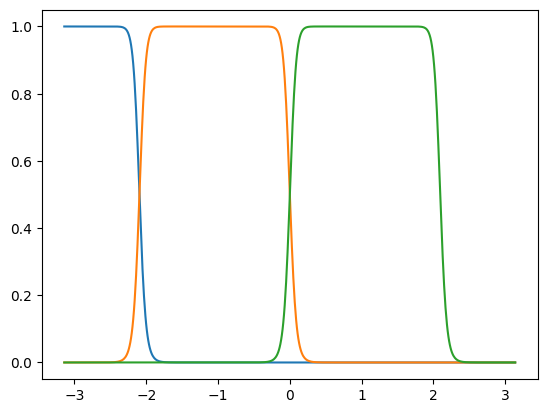

In [6]:

plt.plot(phi,switch(phi,0,w/2))
(print (w/2))
(print (w/2/np.pi))

plt.plot(phi,switch(phi,2*np.pi/3.,w/2))
(print (w/2))
(print (w/2/np.pi))

plt.plot(phi,switch(phi,4*np.pi/3.,w/2))
(print (w/2))
(print (w/2/np.pi))


In [7]:
switch(2*np.pi/3 -1,2*np.pi/3.,w/2)

array([3.49141903e-08])

In [8]:
counter3 ([2.0])

0 2.0
[1.81224213]
[1.81224213]


array([1.81224213])

In [9]:
w/2

1.0471975511965976

In [10]:
x =np.array([np.pi*2-0.1])

x

array([6.18318531])

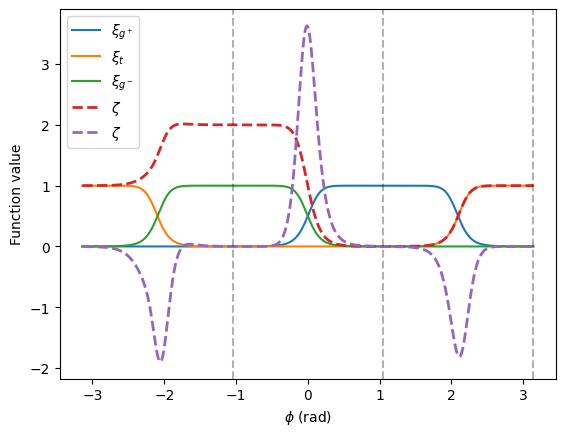

In [59]:
import numpy as np
import matplotlib.pyplot as plt

phi = np.linspace(-np.pi, np.pi, 1000)
r0 = np.pi/3
n = 12
m = 2*n

def wrap_to_pi(x): return (x + np.pi) % (2*np.pi) - np.pi

def xi(phi, d0, r0, n=24, m=48):
    dphi = wrap_to_pi(phi-d0)
    x = dphi/r0
    return (1 - x**n) / (1 - x**m)

xi_gp = xi(phi,  np.pi/3,  r0, n, m)
xi_t  = xi(phi,  np.pi,    r0, n, m)
xi_gm = xi(phi, -np.pi/3,  r0, n, m)

zeta = 1*xi_t + 2*xi_gm

plt.figure()
plt.plot(phi, xi_gp, label=r'$\xi_{g^+}$')
plt.plot(phi, xi_t,  label=r'$\xi_{t}$')
plt.plot(phi, xi_gm, label=r'$\xi_{g^-}$')
plt.plot(phi, zeta, '--', label=r'$\zeta$',  linewidth=2)
plt.plot(phi[1:], -100*np.diff(zeta), '--', label=r'$\zeta$',  linewidth=2)

plt.axvline(np.pi, linestyle='--', color='k', alpha=0.3)
plt.axvline(np.pi/3, linestyle='--', color='k', alpha=0.3)
plt.axvline(-np.pi/3, linestyle='--', color='k', alpha=0.3)
plt.xlabel(r'$\phi$ (rad)')
plt.ylabel('Function value')
plt.legend()
plt.show()

In [60]:
def zeta2D(phi1,phi2):
    
    xi1_gp = xi(phi1,  np.pi/3,  r0, n, m)
    xi1_t  = xi(phi1,  np.pi,    r0, n, m)
    xi1_gm = xi(phi1, -np.pi/3,  r0, n, m)
    xi2_gp = xi(phi2,  np.pi/3,  r0, n, m)
    xi2_t  = xi(phi2,  np.pi,    r0, n, m)
    xi2_gm = xi(phi2, -np.pi/3,  r0, n, m)

    
    return 1*xi1_t + 2*xi1_gm + 3 * (1*xi2_t + 2*xi2_gm )


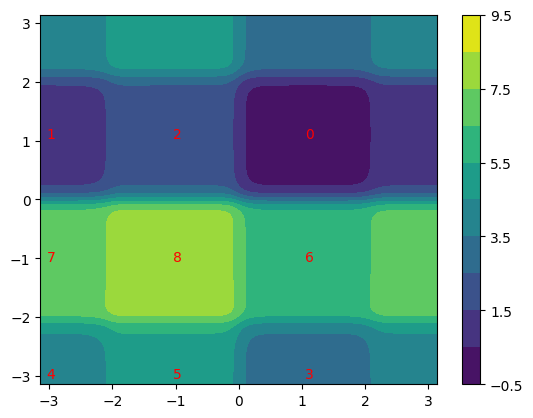

In [86]:
fig,ax= plt.subplots()
dx = 0.01
x = np.arange(-np.pi, np.pi,dx)
X, Y = np.meshgrid(x, x)
points = np.vstack([X.flatten(),Y.flatten()]).T
ctr = ax.contourf(x, x, zeta2D(X,Y),levels=np.array([0,1,2,3,4,5,6,7,8,9,10])-0.5)
for m1 in [-np.pi/3, np.pi/3, -np.pi+0.1]:
    for m2 in [-np.pi/3, np.pi/3, -np.pi+0.1]:
        val = zeta2D(m1,m2)
        ax.annotate(str(int(val)),xy=(m1, m2),c='r')
fig.colorbar(ctr)

In [53]:
zeta2D(X,Y).shape

(7, 7)